# 11. Deeper Noise: Cells, Ridges, and Warped Space

Chapter 10 met coherent noise and let it blow particles around. Today we stay with the noise itself and learn three deeper moves from the texture-maker's workshop: distance fields that crystallize into cells, folded octaves that crease into ridges, and the strangest of the three, noise used to bend the very space it lives in.

## Today's destination

A slab of imaginary geology: strata that fold, pinch and swirl like polished stone, rendered in a custom mineral palette. No stroke of it is drawn. A ridged noise field supplies the strata, and then the field is pushed *through itself*, twice: every pixel goes to look up its value not at its own location but at a spot displaced by more noise, and the straight bands smear into currents. The move is called domain warping, and it is as close as this book comes to a magic trick. By the end of today you will perform it, and its two workshop siblings, on any image-like array you own.

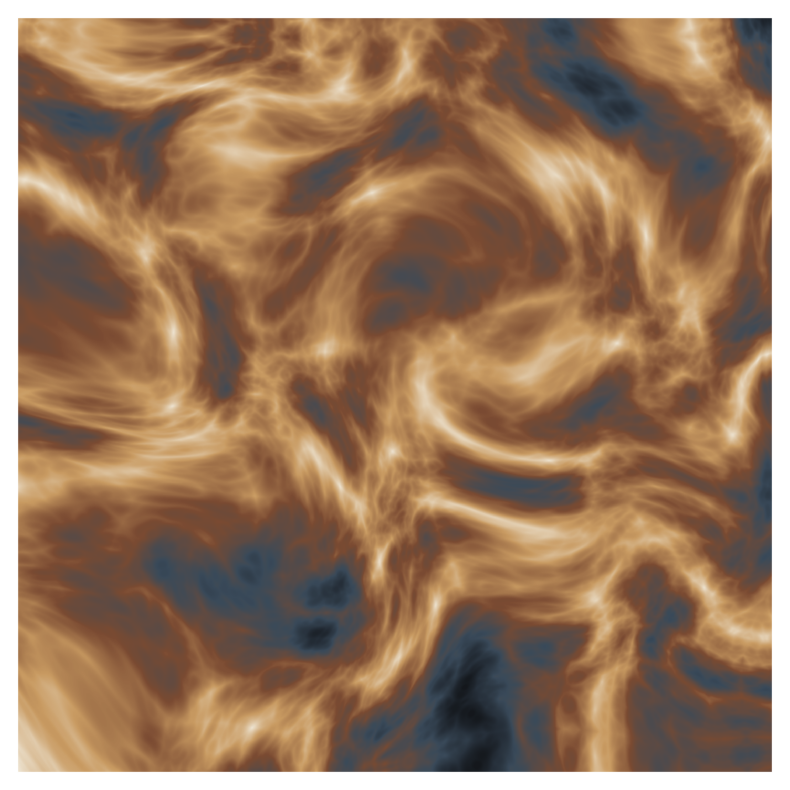

In [1]:
# display this chapter's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/ch11_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: one bookshelf, one workshop

The craft this chapter teaches has an unusually compact address. In 1994, five graphics programmers published a shared volume, *Texturing and Modeling: A Procedural Approach* (<a class="cite" href="#ref-ebert1994">Ebert, Musgrave, Peachey, Perlin, Worley</a>), and the chapter you are reading descends almost entirely from three of its authors. **Ken Perlin** you met in chapter 10: his 1985 noise <a class="cite" href="#ref-perlin1985">(Perlin 1985)</a>, born of frustration with the machine-clean look of *Tron*, is the raw material for everything below. **Steven Worley** added the second instrument at SIGGRAPH 1996, "A Cellular Texture Basis Function" <a class="cite" href="#ref-worley1996">(Worley 1996)</a>: scatter feature points in space and ask, for every pixel, *how far is the nearest one?* The resulting distance fields shade into cobblestones, cells and cracked glazes, and Worley noise remains a standard name for it. **F. Kenton Musgrave**, Mandelbrot's former research assistant at Yale <a class="cite" href="#ref-musgrave1993">(Musgrave 1993)</a> (Mandelbrot called him "the first true fractal-based artist" <a class="cite" href="#ref-taylor2014">(Taylor 2014)</a>), contributed the third: his ridged multifractal, published as working code in that same shared book, folds each noise octave before stacking so that smooth hills sharpen into mountain crests; after directing advanced 3D research at MetaCreations, maker of the landscape software Bryce, he built his fractal planets into his own software MojoWorld (<a class="cite" href="#ref-metacreations">MetaCreations, archived product page</a>; <a class="cite" href="#ref-musgrave2014">Musgrave, resume</a>). The craft's contemporary canon lives on the web: **Inigo Quilez**, co-creator of Shadertoy (2013), maintains at iquilezles.org the articles on cellular noise and domain warping that today's shader artists learn from, including the formula this chapter closes with <a class="cite" href="#ref-quilez">(Quilez, "Domain Warping")</a>.

But the chapter's emotional center is far older than computer graphics. For centuries, bookbinders' marbled endpapers have been made by floating pigment on thickened liquid and dragging combs and styluses through it: Ottoman *ebru* (inscribed by UNESCO as intangible cultural heritage in 2014; <a class="cite" href="#ref-unesco">UNESCO, Representative List entry</a>) and Japanese *suminagashi*, ink floated on water, commonly dated back to the Heian period <a class="cite" href="#ref-chambers1991">(Chambers 1991)</a>. Look closely at a marbled paper: the colors were laid down in plain drops and stripes, and every feather and swirl is the *carrier being deformed*. Marbling is domain warping performed with physical matter, five hundred years before anyone could name the mathematics; when the code below bends a striped field into eddies, you are watching the marbler's comb.

And the cellular look has its own art-historical double: **craquelure** (Krakelee), the crack networks of aged paint and fired glazes, which Song-dynasty Chinese potters promoted from kiln defect to the entire decoration of Guan and Ge ware ("golden thread and iron wire", the connoisseurs' name for Ge ware's two-scale crack net; <a class="cite" href="#ref-nilsson">Nilsson, glossary entry</a>; <a class="cite" href="#ref-xie2007">Xie et al. 2007</a>). Chapter 14 will *grow* such patterns from simulated chemistry; Worley conjures them from geometry alone, and comparing the two ways of arriving at one look is Part III's quiet running theme.

## Worley noise: the nearest-seed field

The recipe is almost embarrassingly short. Scatter a few dozen **seed points** in the plane. Then, for every pixel $p$, measure

$$F_1(p) = \text{distance to the nearest seed}, \qquad F_2(p) = \text{distance to the second-nearest},$$

read aloud: *stand at the pixel, look around, note how far the closest and the next-closest seeds are.* $F_1$ alone makes a field of soft dark basins (dark = a seed is near) with bright watersheds between them. The difference $F_2 - F_1$ is subtler and better: it is zero exactly where the two nearest seeds tie, which happens on the *border* between their territories, and grows as you move into either territory. Worley's 1996 paper already knew what that was good for: rendered as brightness, $F_2 - F_1$ draws "a latticework of connected ridges, forming a vein-like tracery", his words <a class="cite" href="#ref-worley1996">(Worley 1996)</a>, and one of art history's oldest surface decorations falls out of a subtraction.

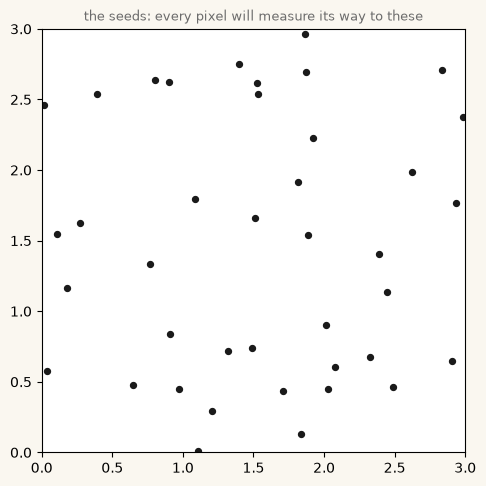

In [2]:
# forty seeds on a square: the cast of the whole first act
import sys
import numpy as np

sys.path.append("..")                       # make the course package importable
from agap.helpers import PAPER, PALETTES, save_artwork

GRID = 600                                  # canonical resolution; raise for prints
rng = np.random.default_rng(7)              # chapter 2's seeded generator
seeds = rng.random((40, 2)) * 3             # 40 points in a 3-by-3 world

fig, ax = plt.subplots(figsize=(5.5, 5.5), facecolor=PAPER)
ax.scatter(seeds[:, 0], seeds[:, 1], s=18, color="#1A1A1A")
ax.set_xlim(0, 3)
ax.set_ylim(0, 3)
ax.set_aspect("equal")
ax.set_title("the seeds: every pixel will measure its way to these",
             fontsize=9, color="#6B6B6B")
plt.show()

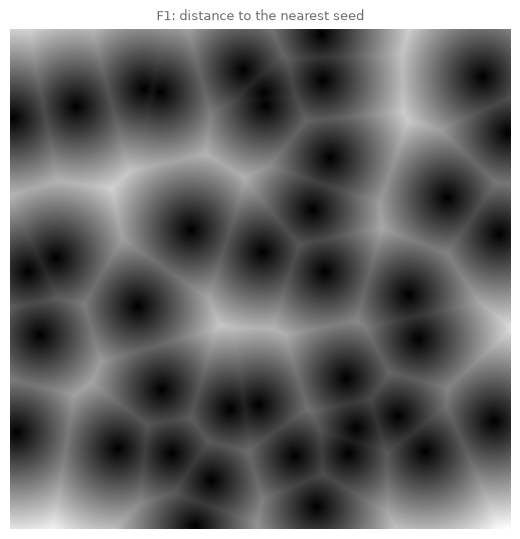

In [3]:
# F1 the honest way: one seed at a time, keeping the running minimum
axis = np.linspace(0, 3, GRID)
xx, yy = np.meshgrid(axis, axis)            # chapter 8's pixel-coordinate move

f1 = np.full((GRID, GRID), np.inf)          # start: nearest seed infinitely far
for sx, sy in seeds:
    distance = np.hypot(xx - sx, yy - sy)   # this seed's distance to every pixel
    f1 = np.minimum(f1, distance)           # keep whichever is nearer

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.imshow(f1, cmap="gray", origin="lower")
ax.set_title("F1: distance to the nearest seed", fontsize=9, color="#6B6B6B")
ax.axis("off")
plt.show()

Stone. Specifically: a cobbled surface lit from nowhere, each basin one seed's territory, the bright ridges the no-man's-land between territories. The loop is worth reading twice, because its shape recurs all chapter: *for each seed, compute a whole image of distances, and fold it into the running answer with `np.minimum`*. Forty seeds means forty vectorized sweeps over the pixel grid, and NumPy does the million-pixel arithmetic while Python only turns the pages. (The same forty sweeps could be written in one line, `np.min(np.stack(all_distance_images), axis=0)`, at the price of holding all forty images in memory at once; the running-minimum loop keeps just one and scales to any seed count.)

For $F_2$ we track *two* running values: when a closer seed appears, the old champion becomes the runner-up.

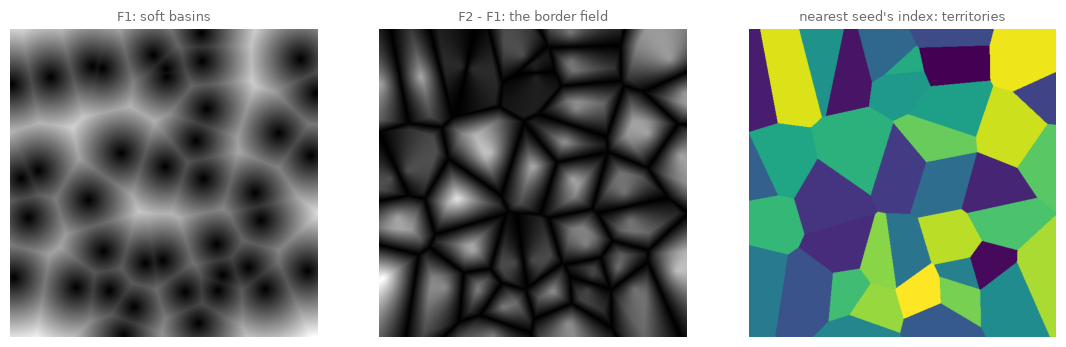

In [4]:
# F1 and F2 together, and the fields they unlock
f1 = np.full((GRID, GRID), np.inf)
f2 = np.full((GRID, GRID), np.inf)
nearest_index = np.zeros((GRID, GRID), dtype=int)
for index, (sx, sy) in enumerate(seeds):
    distance = np.hypot(xx - sx, yy - sy)
    closer = distance < f1                  # does this seed beat the champion?
    f2 = np.where(closer, f1, np.minimum(f2, distance))
    f1 = np.where(closer, distance, f1)
    nearest_index = np.where(closer, index, nearest_index)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6))
for ax, field, cmap, title in [
        (axes[0], f1, "gray", "F1: soft basins"),
        (axes[1], f2 - f1, "gray", "F2 - F1: the border field"),
        (axes[2], nearest_index, "viridis", "nearest seed's index: territories")]:
    ax.imshow(field, cmap=cmap, origin="lower")
    ax.set_title(title, fontsize=9, color="#6B6B6B")
    ax.axis("off")
plt.show()

**Look and compare.** The middle panel is the cracked glaze: dark veins exactly on the territory borders, Worley's tracery, Ge ware by subtraction. The right panel colors each pixel by *which* seed is nearest rather than *how far* it is, and the territories snap into flat cells. Those cells have a name, and chapter 15 will earn it properly: this is a Voronoi diagram, and there we will harvest the regions themselves (their areas, their centers, their polygons) rather than rendering their distances as texture, as today. Same geometry, two different harvests.

**Try it.** Change the seed count to 12 and to 200 and rerun the cell: the glaze coarsens into flagstones or tightens into skin. Seed density is the material's grain.

## Ridged noise: fold before you stack

Chapter 10 stacked octaves of noise into fbm: hills upon hills, all rounded, because noise crosses zero *smoothly*. Musgrave's move is one line of surgery on each octave before it joins the sum: replace the octave's value $n$ with

$$1 - |n|,$$

read aloud: *distance below the ceiling.* Wherever the raw octave crossed zero, $|n|$ has a sharp V-shaped crease, so $1 - |n|$ has a sharp inverted crest, and the smooth hill becomes a knife-edged ridge. Sum the folded octaves with the usual shrinking amplitudes and the creases of every scale interleave: mountains. (Musgrave's full ridged multifractal goes one step further and lets each octave's strength be modulated by the one before it, so detail gathers on the crests and the valleys stay smooth; that refinement is out of our scope, and the additive version below already makes convincing rock.)

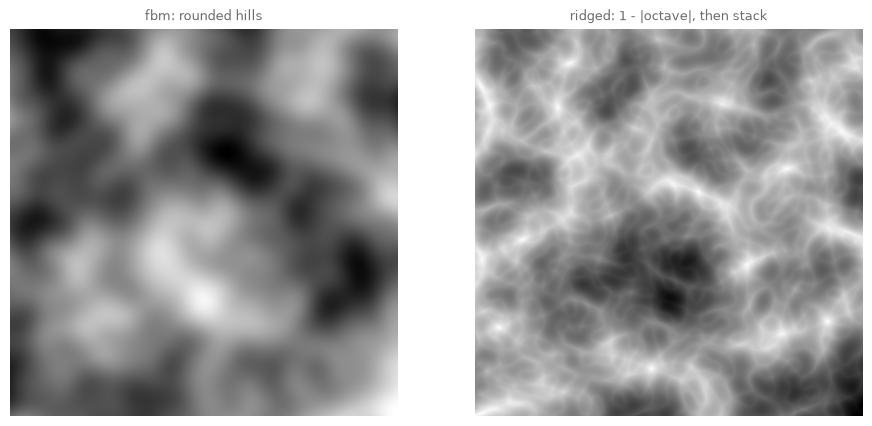

In [5]:
# fbm vs ridged: the same octaves, one fold apart
import opensimplex

def fbm(xs, ys, octaves=3, persistence=0.5, lacunarity=2.0):
    # chapter 10's octave_noise, condensed: stack noise at doubling frequencies
    total = np.zeros((len(ys), len(xs)))
    amplitude, frequency = 1.0, 1.0
    for _ in range(octaves):
        total += amplitude * opensimplex.noise2array(xs * frequency, ys * frequency)
        amplitude *= persistence
        frequency *= lacunarity
    return total / np.max(np.abs(total))

def ridged(xs, ys, octaves=4, persistence=0.5, lacunarity=2.0):
    total = np.zeros((len(ys), len(xs)))
    amplitude, frequency = 1.0, 1.0
    for _ in range(octaves):
        octave = opensimplex.noise2array(xs * frequency, ys * frequency)
        total += amplitude * (1 - np.abs(octave))    # the fold: crease at zero
        amplitude *= persistence
        frequency *= lacunarity
    return total / np.max(np.abs(total))

opensimplex.seed(11)
smooth_field = fbm(axis, axis)
opensimplex.seed(11)
ridged_field = ridged(axis, axis)

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
for ax, field, title in [(axes[0], smooth_field, "fbm: rounded hills"),
                         (axes[1], ridged_field, "ridged: 1 - |octave|, then stack")]:
    ax.imshow(field, cmap="gray", origin="lower")
    ax.set_title(title, fontsize=9, color="#6B6B6B")
    ax.axis("off")
plt.show()

**Look and compare.** Same seed, same octaves, and the left panel is weather while the right is terrain. The fold manufactures exactly what smooth noise cannot: *lines*, the bright connected crests where an octave crossed zero, reading instantly as ridgelines, veins of quartz, dried riverbeds. Squint at the right panel and it is already a relief map of nowhere.

## Domain warping: noise bends space

The third move is the deep one. So far noise has always answered the question *what value lives at $p$?* Domain warping changes the question: evaluate the field not at $p$ but at a spot that noise points to,

$$f\big(p + a \cdot d(p)\big),$$

read aloud: *go to $p$, ask a displacement field $d$ (Verschiebung) which way to shove you and shove yourself by $a$ times that, then read $f$ where you land.* In the purest, self-referential version $d$ is $f$ itself, the field bending its own canvas; in practice, and in Quilez's canonical article, the shove gets its own pair of noise fields, one per axis, so that it has a direction and not just a strength. The dial $a$ sets how hard the shove is, and iterating the trick (warp the already-warped field) compounds the folding the way the marbler's second comb-pass drags the first pass's stripes into feathers.

One practical detour, and it is this chapter's one true black box. Our `noise2array` evaluates on rectilinear grids only: it can hand us *the field as an image*, but not "the field at these million scattered landing spots". So we do what photographers do with an enlarger: precompute the field as a fine image once, then read it at arbitrary coordinates with `scipy.ndimage.map_coordinates`, which looks up positions *between* the stored pixels by blending their neighbors (skim its call below; the one idea is that it reads between the pixels, so a landing spot of row 41.7 gets a 30/70 blend of rows 41 and 42). Everything else in the cell is arithmetic you already own.

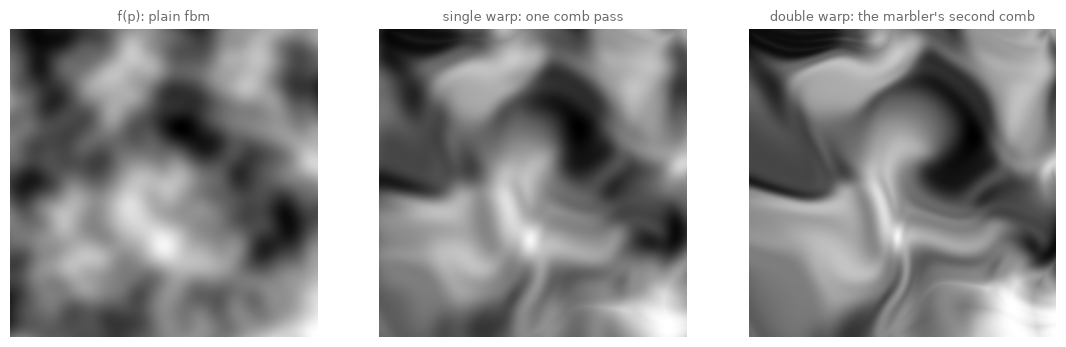

In [6]:
# the marbling machine: fbm, warped, warped again
from scipy.ndimage import map_coordinates

opensimplex.seed(23)
shove_x = fbm(axis, axis, octaves=2)        # one noise field per displacement axis
opensimplex.seed(59)
shove_y = fbm(axis, axis, octaves=2)

def warp(field, amplitude_pixels):
    """Read `field` at positions displaced by the shove fields (in pixels)."""
    rows, cols = np.meshgrid(np.arange(GRID), np.arange(GRID), indexing="ij")
    return map_coordinates(field,
                           [rows + amplitude_pixels * shove_y,
                            cols + amplitude_pixels * shove_x],
                           order=1, mode="reflect")

once = warp(smooth_field, 60)
twice = warp(once, 60)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6))
for ax, field, title in [(axes[0], smooth_field, "f(p): plain fbm"),
                         (axes[1], once, "single warp: one comb pass"),
                         (axes[2], twice, "double warp: the marbler's second comb")]:
    ax.imshow(field, cmap="gray", origin="lower")
    ax.set_title(title, fontsize=9, color="#6B6B6B")
    ax.axis("off")
plt.show()

**Look and compare.** Left to right is five hundred years of marbling compressed into two function calls. The plain field's soft blobs stretch into currents, and the currents fold into eddies with hooked tails, the exact vocabulary of an ebru endpaper. Nothing was drawn; a field of values was *transported*.

**Try it.** The amplitude 60 is in pixels, a tenth of the image. Halve it and the marbling relaxes toward the original; double it and space tears into streaks. Exercise (a) walks this dial properly.

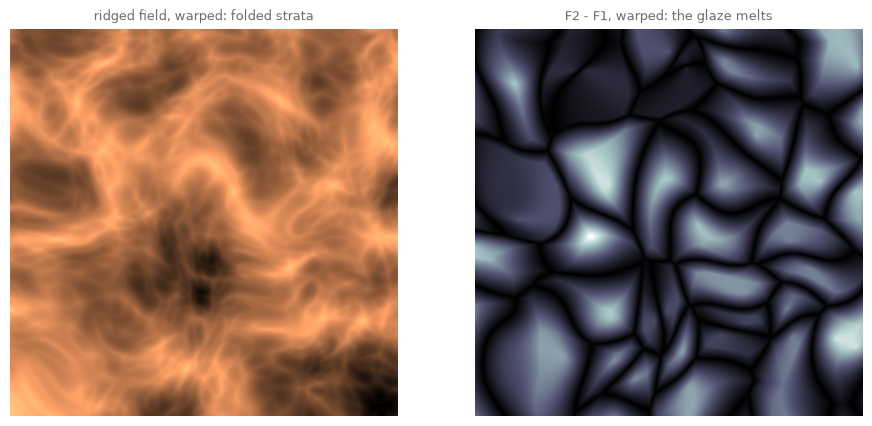

In [7]:
# the instruments combined: warped ridges, melting cells
warped_ridged = warp(ridged_field, 45)
melting_cells = warp(f2 - f1, 55)

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
for ax, field, cmap, title in [
        (axes[0], warped_ridged, "copper", "ridged field, warped: folded strata"),
        (axes[1], melting_cells, "bone", "F2 - F1, warped: the glaze melts")]:
    ax.imshow(field, cmap=cmap, origin="lower")
    ax.set_title(title, fontsize=9, color="#6B6B6B")
    ax.axis("off")
plt.show()

**Look and compare.** Everything composes with everything: the warp does not care that one field came from folded octaves and the other from measured distances. The left panel's crests now meander like rock strata seen in a cliff face; the right panel's crack network sags as if the glaze refired and began to flow. This composability is the workshop's real lesson, and it is why the five authors could share one book: procedural texturing is a small set of field-makers (noise, distances) and field-benders (folds, warps) that combine without asking permission.

## Parameter studies: four temperaments of one machine

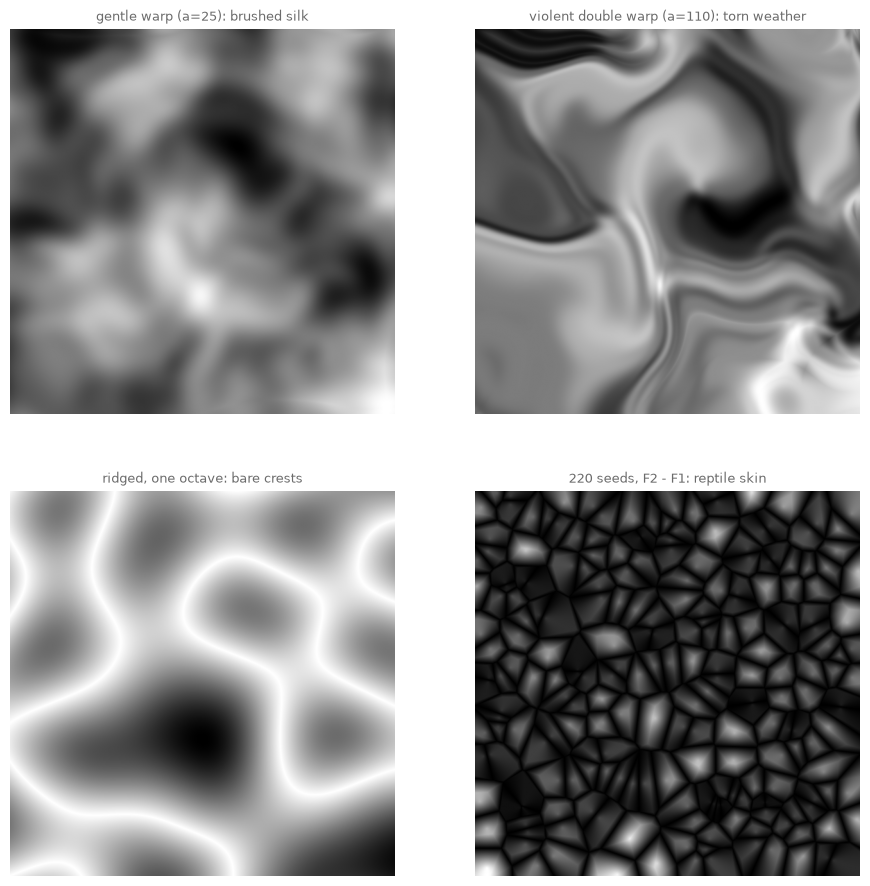

In [8]:
# four labeled studies: the dials are amplitude, octaves, and seed density
fig, axes = plt.subplots(2, 2, figsize=(11, 11))

axes[0, 0].imshow(warp(smooth_field, 25), cmap="gray", origin="lower")
axes[0, 0].set_title("gentle warp (a=25): brushed silk", fontsize=9, color="#6B6B6B")

axes[0, 1].imshow(warp(warp(smooth_field, 110), 110), cmap="gray", origin="lower")
axes[0, 1].set_title("violent double warp (a=110): torn weather", fontsize=9,
                     color="#6B6B6B")

opensimplex.seed(11)
axes[1, 0].imshow(ridged(axis, axis, octaves=1), cmap="gray", origin="lower")
axes[1, 0].set_title("ridged, one octave: bare crests", fontsize=9, color="#6B6B6B")

dense_rng = np.random.default_rng(7)
dense_seeds = dense_rng.random((220, 2)) * 3
dense_f1 = np.full((GRID, GRID), np.inf)
dense_f2 = np.full((GRID, GRID), np.inf)
for sx, sy in dense_seeds:
    distance = np.hypot(xx - sx, yy - sy)
    closer = distance < dense_f1
    dense_f2 = np.where(closer, dense_f1, np.minimum(dense_f2, distance))
    dense_f1 = np.where(closer, distance, dense_f1)
axes[1, 1].imshow(dense_f2 - dense_f1, cmap="gray", origin="lower")
axes[1, 1].set_title("220 seeds, F2 - F1: reptile skin", fontsize=9, color="#6B6B6B")

for ax in axes.flat:
    ax.axis("off")
plt.show()

**Look and compare.** Four materials from one afternoon of arithmetic: silk, storm, rock, skin. Name which dial made each difference before reading the titles again; if you can do that, you own the machine.

## Export your artwork

Compose your own material: pick a base field (fbm, ridged, or a Worley difference), a warp amplitude (possibly zero, possibly applied twice), and a colormap. Replace `yourname` and run.

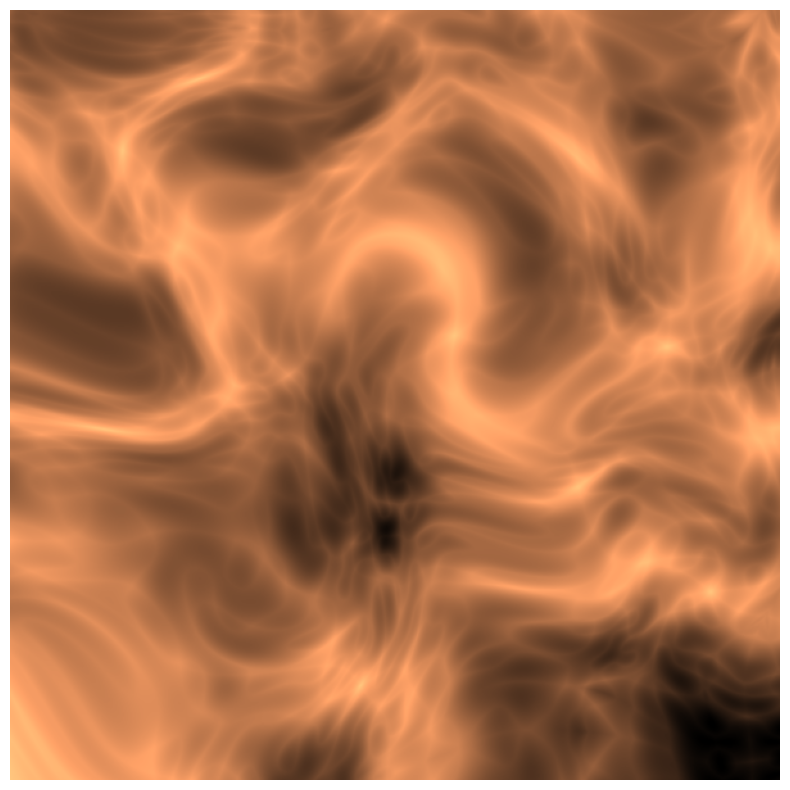

saved: assets/outputs/ch11_yourname.png


In [9]:
# save YOUR texture: choose base field, warp strength, colormap
my_field = warp(warp(ridged_field, 40), 40)
my_artwork, my_ax = plt.subplots(figsize=(10, 10))
my_ax.imshow(my_field, cmap="copper", origin="lower")
my_ax.axis("off")
plt.show()
saved_path = save_artwork(my_artwork, "yourname", chapter=11)

## Exercises

**(a) Parameter exploration: the birth of marbling.** Render `warp(smooth_field, a)` for $a \in \{0, 10, 20, 40, 80, 160\}$ in a row of six panels. Somewhere along that row the image stops being *textured noise* and starts being *marbled paper*: find the panel where the change happens for you, and defend the choice in one sentence (what, exactly, does your eye use as evidence: curvature? layering? the hooked eddy tails?).

**(b) Code modification: Manhattan Worley.** City distance instead of crow's flight: replace `np.hypot(xx - sx, yy - sy)` with $|x - s_x| + |y - s_y|$ in the F1/F2 loop and re-render both $F_1$ and $F_2 - F_1$. Describe how the cells change and why.

<details><summary>Solution</summary>

```python
m1 = np.full((GRID, GRID), np.inf)
m2 = np.full((GRID, GRID), np.inf)
for sx, sy in seeds:
    distance = np.abs(xx - sx) + np.abs(yy - sy)   # Manhattan metric
    closer = distance < m1
    m2 = np.where(closer, m1, np.minimum(m2, distance))
    m1 = np.where(closer, distance, m1)

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
axes[0].imshow(m1, cmap="gray", origin="lower")
axes[0].set_title("Manhattan F1", fontsize=9, color="#6B6B6B")
axes[1].imshow(m2 - m1, cmap="gray", origin="lower")
axes[1].set_title("Manhattan F2 - F1", fontsize=9, color="#6B6B6B")
for ax in axes:
    ax.axis("off")
plt.show()
```

Circles become diamonds: under the Manhattan metric the set of points at a fixed distance from a seed is a square rotated 45 degrees, so the basins grow as diamonds and the borders between territories run preferentially at 45 degrees (with dead-straight horizontal and vertical segments where two seeds share a coordinate). The glaze stops looking organic and starts looking cut, like a tiled floor laid by someone who only owned a diagonal saw.
</details>

**(c) Creative challenge: marble your own past.** Take an image-like array you made earlier in this book (the chapter 2 color grid is the suggested victim: rebuild one with its generator, or load any saved artwork via `mpimg.imread`, which hands back an array with a color channel axis) and push it through `warp`, one `map_coordinates` call per color channel, same shove fields for all three. Start gentle. A marbled Richter grid, a marbled random walk, a marbled Mondrian: your earlier chapters are a drawer of plain papers waiting for the comb. (One practical hurdle: `warp` assumes a 600 by 600 field. Either downsample your image to that size first, `image[::step, ::step]` on each channel, or rebuild the shove fields at your image's size the way the showpiece appendix does.)

## Further reading

- Steven Worley, "A Cellular Texture Basis Function", *SIGGRAPH 96 Proceedings*, 291-294: four dense pages containing this chapter's whole first act, F1, F2, the border tracery and the flagstone cells.
- David S. Ebert, F. Kenton Musgrave, Darwyn Peachey, Ken Perlin and Steven Worley, *Texturing and Modeling: A Procedural Approach* (Academic Press, 1994; 3rd ed. Morgan Kaufmann, 2003): the shared bookshelf itself; Musgrave's terrain chapters include the full ridged multifractal this chapter simplified.
- Inigo Quilez, "Domain Warping" and the cellular-noise articles at iquilezles.org: the contemporary canon, with live shader code; our `warp` function is his construction translated from GPU to NumPy.
- UNESCO Intangible Cultural Heritage list: "Ebru, Turkish art of marbling" (inscribed 2014): a short official portrait of the physical craft this chapter's mathematics imitates.

## References

- <span id="ref-chambers1991"></span>Chambers, A. (1991). *Suminagashi: The Japanese Art of Marbling*. Thames and Hudson. The standard monograph on the craft, its earliest surviving Heian-period papers included.
- <span id="ref-ebert1994"></span>Ebert, D. S., Musgrave, F. K., Peachey, D., Perlin, K., and Worley, S. (1994). *Texturing and Modeling: A Procedural Approach*. AP Professional / Academic Press; 3rd ed. Morgan Kaufmann, 2003. The shared bookshelf; Musgrave's chapters carry the ridged multifractal as working code, and the 3rd edition adds his chapter "MojoWorld: Building Procedural Planets".
- <span id="ref-metacreations"></span>MetaCreations Corporation (1999). Bryce 3D product page, as archived 30 April 1999. [Wayback Machine capture](https://web.archive.org/web/19990430044931/http://www.metacreations.com/products/bryce3d/bryce3d.html). The landscape software in its maker's own words: "dedicated to designing and animating breathtaking natural 3D worlds".
- <span id="ref-musgrave1993"></span>Musgrave, F. K. (1993). *Methods for Realistic Landscape Imaging*. PhD dissertation, Yale University. His doctoral work, carried out under Mandelbrot.
- <span id="ref-musgrave2014"></span>Musgrave, F. K. (2014). About (resume). kenmusgrave.com, as archived 2 November 2014. [Wayback Machine capture](https://web.archive.org/web/20141102020720/http://www.kenmusgrave.com/about.html). Documents his posts as Director of Advanced 3D Research at MetaCreations (1997–1999) and founder-CEO of Pandromeda (1999–2011).
- <span id="ref-nilsson"></span>Nilsson, J.-E. Ge (Wade-Giles: ko) ware. In *Chinese Porcelain Glossary*, gotheborg.com. [gotheborg.com/glossary/ge.shtml](https://www.gotheborg.com/glossary/ge.shtml). The double crackle *jinsi tiexian* ("gold thread and iron wire") as the mark separating Ge from Guan.
- <span id="ref-perlin1985"></span>Perlin, K. (1985). An image synthesizer. *ACM SIGGRAPH Computer Graphics*, 19(3), 287–296. [doi:10.1145/325165.325247](https://doi.org/10.1145/325165.325247). Chapter 10's noise, the raw material of this whole workshop.
- <span id="ref-quilez"></span>Quilez, I. Domain Warping. [iquilezles.org/articles/warp](https://iquilezles.org/articles/warp/). The canonical article our `warp` function translates from GPU to NumPy; his site also carries the cellular-noise articles and records co-founding Shadertoy with Pol Jeremias.
- <span id="ref-taylor2014"></span>Taylor, G. D. (2014). *When the Machine Made Art: The Troubled History of Computer Art*. Bloomsbury Academic. Documents Mandelbrot's description of Musgrave (p. 170).
- <span id="ref-unesco"></span>UNESCO. Ebru, Turkish art of marbling. Representative List of the Intangible Cultural Heritage of Humanity, inscribed 2014. [ich.unesco.org](https://ich.unesco.org/en/RL/ebru-turkish-art-of-marbling-00644). The official portrait of the physical craft.
- <span id="ref-worley1996"></span>Worley, S. (1996). A cellular texture basis function. *SIGGRAPH '96 Proceedings*, 291–294. [doi:10.1145/237170.237267](https://doi.org/10.1145/237170.237267). Four pages: F1, F2, and the vein-like tracery quoted above.
- <span id="ref-xie2007"></span>Xie, G., Feng, S., Feng, X., Wang, Y., Zhu, J., Yan, L., Li, Y., and Han, H. (2007). Study on ancient Chinese imitated GE ware by INAA and WDXRF. *Nuclear Instruments and Methods in Physics Research Section B*, 264(1), 103–108. [doi:10.1016/j.nimb.2007.08.017](https://doi.org/10.1016/j.nimb.2007.08.017). The two-colored crazing "called 'golden thread and iron wire'", here under nuclear analysis.


---
### Appendix: regenerate the showpiece

This last cell (re)creates the image at the top of the notebook: a five-octave ridged field on a wider window (span 4.5) at 900 by 900, double-warped by upsampled shove fields, in a custom five-stop mineral colormap (basalt, slate, iron oxide, sand, bone). About 25 seconds; it runs automatically with *Restart & Run All*.

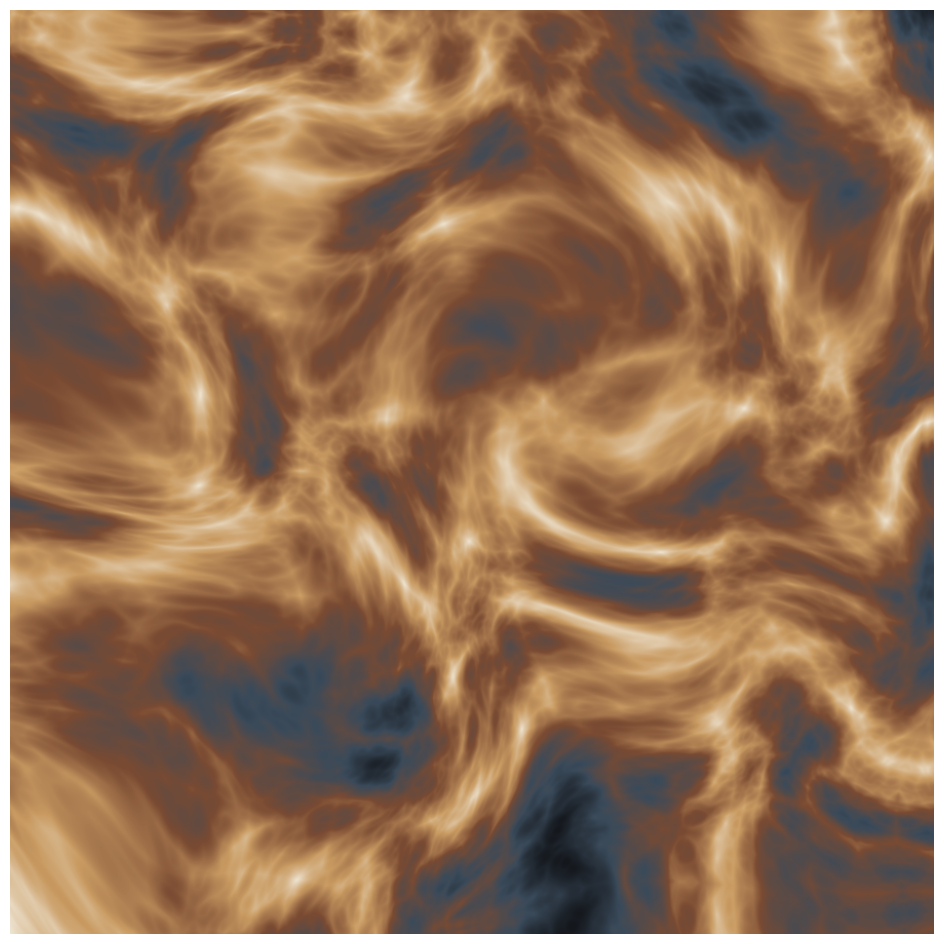

saved: assets/outputs/ch11_showpiece.png


In [10]:
# regenerate this chapter's showpiece: folded strata, twice combed
from matplotlib.colors import LinearSegmentedColormap

MINERAL = LinearSegmentedColormap.from_list(
    "mineral", ["#14171C", "#3A4A5A", "#7A4A32", "#C99B62", "#EFE6D5"])

SP_GRID = 900
sp_axis = np.linspace(0, 4.5, SP_GRID)
opensimplex.seed(11)
sp_ridged = ridged(sp_axis, sp_axis, octaves=5)

# shove fields upsampled from the chapter's 600-pixel ones: displacement is
# smooth by nature, so it survives enlargement (map_coordinates again)
fine = np.linspace(0, GRID - 1, SP_GRID)
fine_rows, fine_cols = np.meshgrid(fine, fine, indexing="ij")
sp_shove_x = map_coordinates(shove_x, [fine_rows, fine_cols], order=1)
sp_shove_y = map_coordinates(shove_y, [fine_rows, fine_cols], order=1)

def sp_warp(field, amplitude_pixels):
    rows, cols = np.meshgrid(np.arange(SP_GRID), np.arange(SP_GRID),
                             indexing="ij")
    return map_coordinates(field,
                           [rows + amplitude_pixels * sp_shove_y,
                            cols + amplitude_pixels * sp_shove_x],
                           order=1, mode="reflect")

sp_field = sp_warp(sp_warp(sp_ridged, 54), 54)
showpiece, sp_ax = plt.subplots(figsize=(12, 12))
sp_ax.imshow(sp_field, cmap=MINERAL, origin="lower")
sp_ax.axis("off")
plt.show()
saved_path = save_artwork(showpiece, "showpiece", chapter=11)